# Lab 8 : Visualisation de Donnees Textuelles (Text Data Visualization)

Dans ce lab, nous explorons des techniques de **visualisation de donnees textuelles** a travers l'analyse d'avis produits en ligne.

## Objectifs du Lab
1. **Word Cloud** : Visualiser les mots les plus frequents par categorie de sentiment
2. **Analyse de Frequence** : Identifier les termes-cles avec des graphiques en barres
3. **Distribution de Sentiment** : Visualiser la repartition des sentiments
4. **Analyse Polarite/Subjectivite** : Explorer la relation entre polarite et subjectivite
5. **NER (Named Entity Recognition)** : Extraire et visualiser les entites nommees avec SpaCy

## Dataset
15 **avis produits** (en anglais) avec 3 categories de sentiment :
- **Positifs** : 7 avis
- **Negatifs** : 6 avis
- **Neutres** : 2 avis

## Librairies Utilisees
| Librairie | Usage |
|-----------|-------|
| `WordCloud` | Generation des nuages de mots |
| `Matplotlib` | Visualisations graphiques |
| `Seaborn` | Graphiques statistiques |
| `TextBlob` | Analyse de sentiment (polarity, subjectivity) |
| `SpaCy` | Named Entity Recognition (NER) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from collections import Counter

from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
import spacy

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

print('=' * 60)
print('IMPORTS - VERIFICATION DES LIBRAIRIES')
print('=' * 60)
print('  WordCloud  : OK')
print('  Matplotlib : OK')
print('  Seaborn    : OK')
print('  TextBlob   : OK')
print('  SpaCy      : OK')
print('=' * 60)

IMPORTS - VERIFICATION DES LIBRAIRIES
  WordCloud  : OK
  Matplotlib : OK
  Seaborn    : OK
  TextBlob   : OK
  SpaCy      : OK


## Dataset : Avis Produits

Le dataset contient **15 avis produits** avec leur sentiment associe.
Ces avis couvrent des experiences variees : qualite du produit, service client, rapport qualite/prix.

**Pourquoi ce dataset ?**
- Petite taille mais representatif des 3 classes de sentiment
- Vocabulaire varie pour illustrer les techniques de visualisation
- Reflet de cas reels de NLP en entreprise (e-commerce, satisfaction client)

In [2]:
# ============================================================
# DATASET : 15 AVIS PRODUITS AVEC SENTIMENT ASSOCIE
# ============================================================

reviews_with_sentiment = [
    ('This product is absolutely amazing! I love it so much.', 'positive'),
    ('The features are fantastic and it works perfectly.', 'positive'),
    ('I am extremely happy with this purchase. Highly recommended!', 'positive'),
    ('What a terrible experience. The product broke after just one use.', 'negative'),
    ('This is the worst item I have ever bought. Complete waste of money.', 'negative'),
    ('I was so disappointed. It did not meet my expectations at all.', 'negative'),
    ("It's okay, but nothing special. Could be better.", 'neutral'),
    ("Good value for the price. I'm satisfied.", 'positive'),
    ('The customer service was awful and unhelpful.', 'negative'),
    ('Really impressed with the quality and performance!', 'positive'),
    ("Meh, it's alright. Not great, not bad.", 'neutral'),
    ('Avoid this product at all costs! Seriously flawed.', 'negative'),
    ('So glad I bought this! It has made my life easier.', 'positive'),
    ('The setup was confusing and the instructions were unclear.', 'negative'),
    ('A solid product that does exactly what it says.', 'positive'),
]

positive_reviews = [r for r, s in reviews_with_sentiment if s == 'positive']
negative_reviews = [r for r, s in reviews_with_sentiment if s == 'negative']
neutral_reviews  = [r for r, s in reviews_with_sentiment if s == 'neutral']
positive_text = ' '.join(positive_reviews)
negative_text = ' '.join(negative_reviews)
all_text      = ' '.join([r for r, _ in reviews_with_sentiment])

print('=' * 70)
print('DATASET - STATISTIQUES')
print('=' * 70)
print(f'  Total d avis       : {len(reviews_with_sentiment)}')
print(f'  Avis positifs      : {len(positive_reviews)}')
print(f'  Avis negatifs      : {len(negative_reviews)}')
print(f'  Avis neutres       : {len(neutral_reviews)}')
print(f'  Mots totaux        : {len(all_text.split())}')
print()
print('Exemples :')
print(f'  [POSITIF] {positive_reviews[0]}')
print(f'  [NEGATIF] {negative_reviews[0]}')
print(f'  [NEUTRE ] {neutral_reviews[0]}')

DATASET - STATISTIQUES
  Total d avis       : 15
  Avis positifs      : 7
  Avis negatifs      : 6
  Avis neutres       : 2
  Mots totaux        : 136

Exemples :
  [POSITIF] This product is absolutely amazing! I love it so much.
  [NEGATIF] What a terrible experience. The product broke after just one use.
  [NEUTRE ] It's okay, but nothing special. Could be better.


## Step 1 : Word Clouds - Nuages de Mots par Sentiment

### Justification du Word Cloud
Le **Word Cloud** (nuage de mots) est particulierement adapte pour :
- Visualiser d'un seul coup d'oeil les **termes dominants** dans un corpus
- Comparer le **vocabulaire** entre differentes categories (positif vs negatif)
- Communiquer des resultats textuels de facon **intuitive et visuelle**

> **Principe** : Plus un mot apparait frequemment, plus il est affiche en grand.

On genere deux word clouds separes pour mettre en evidence les differences de vocabulaire.

STEP 1 : WORD CLOUDS - POSITIF vs NEGATIF
------------------------------------------------------------


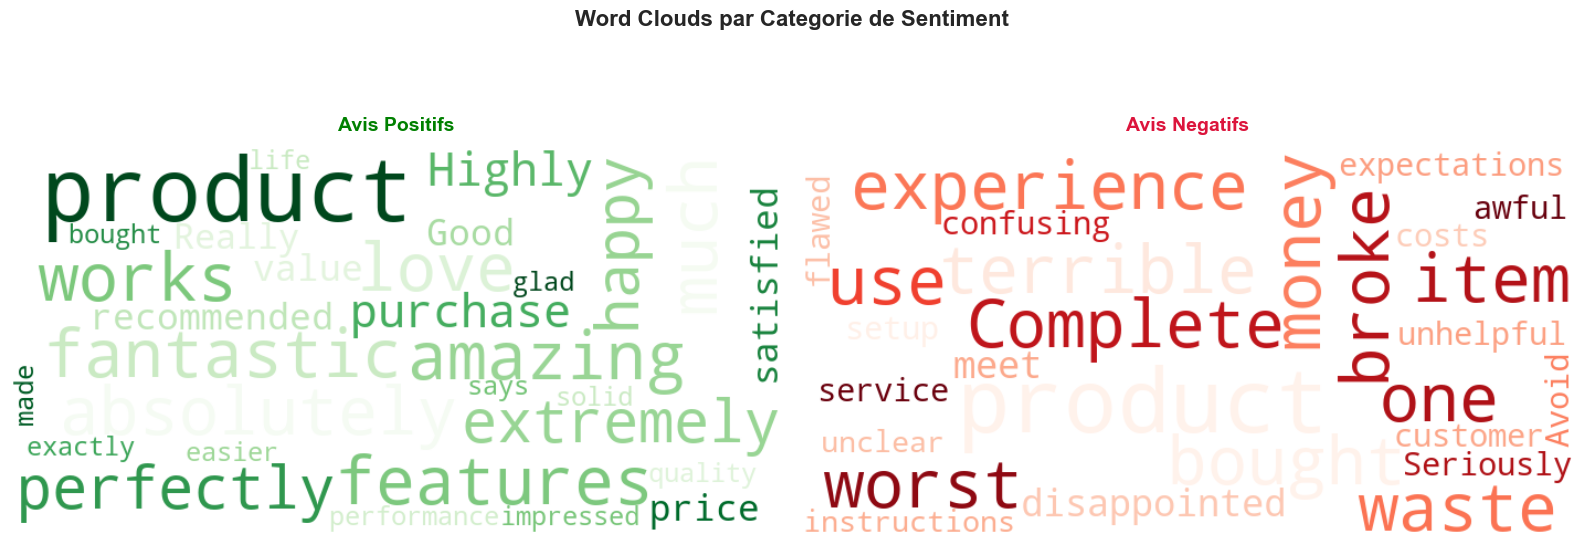

Vocabulaire positif dominant : amazing, love, fantastic, happy, great
Vocabulaire negatif dominant : terrible, worst, disappointed, awful, waste
-> Le vocabulaire est clairement differencie entre les deux categories.


In [3]:
# ============================================================
# STEP 1 : WORD CLOUDS POSITIF vs NEGATIF
# ============================================================
print('STEP 1 : WORD CLOUDS - POSITIF vs NEGATIF')
print('-' * 60)

stopwords = set(STOPWORDS)

wc_positive = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=stopwords,
    colormap='Greens',
    min_font_size=10, max_font_size=80,
    prefer_horizontal=0.9
).generate(positive_text)

wc_negative = WordCloud(
    width=700, height=350,
    background_color='white',
    stopwords=stopwords,
    colormap='Reds',
    min_font_size=10, max_font_size=80,
    prefer_horizontal=0.9
).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Word Clouds par Categorie de Sentiment', fontsize=16, fontweight='bold', y=1.02)

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].set_title('Avis Positifs', fontsize=14, fontweight='bold', color='green', pad=12)
axes[0].axis('off')

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].set_title('Avis Negatifs', fontsize=14, fontweight='bold', color='crimson', pad=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('Vocabulaire positif dominant : amazing, love, fantastic, happy, great')
print('Vocabulaire negatif dominant : terrible, worst, disappointed, awful, waste')
print('-> Le vocabulaire est clairement differencie entre les deux categories.')

## Step 2 : Analyse de Frequence des Mots

### Justification du Graphique en Barres
Un **graphique en barres** de frequence est ideal pour :
- **Quantifier** precisement la frequence de chaque mot (vs word cloud qui est qualitatif)
- **Comparer** les frequences entre mots de facon rigoureuse
- Identifier les **stop words** restants et valider le pretraitement

### Pre-traitement applique
1. Mise en minuscules
2. Suppression de la ponctuation
3. Filtrage des stop words (mots vides : 'the', 'a', 'is'...)
4. Filtrage des mots tres courts (< 3 caracteres)

STEP 2 : ANALYSE DE FREQUENCE DES MOTS
------------------------------------------------------------


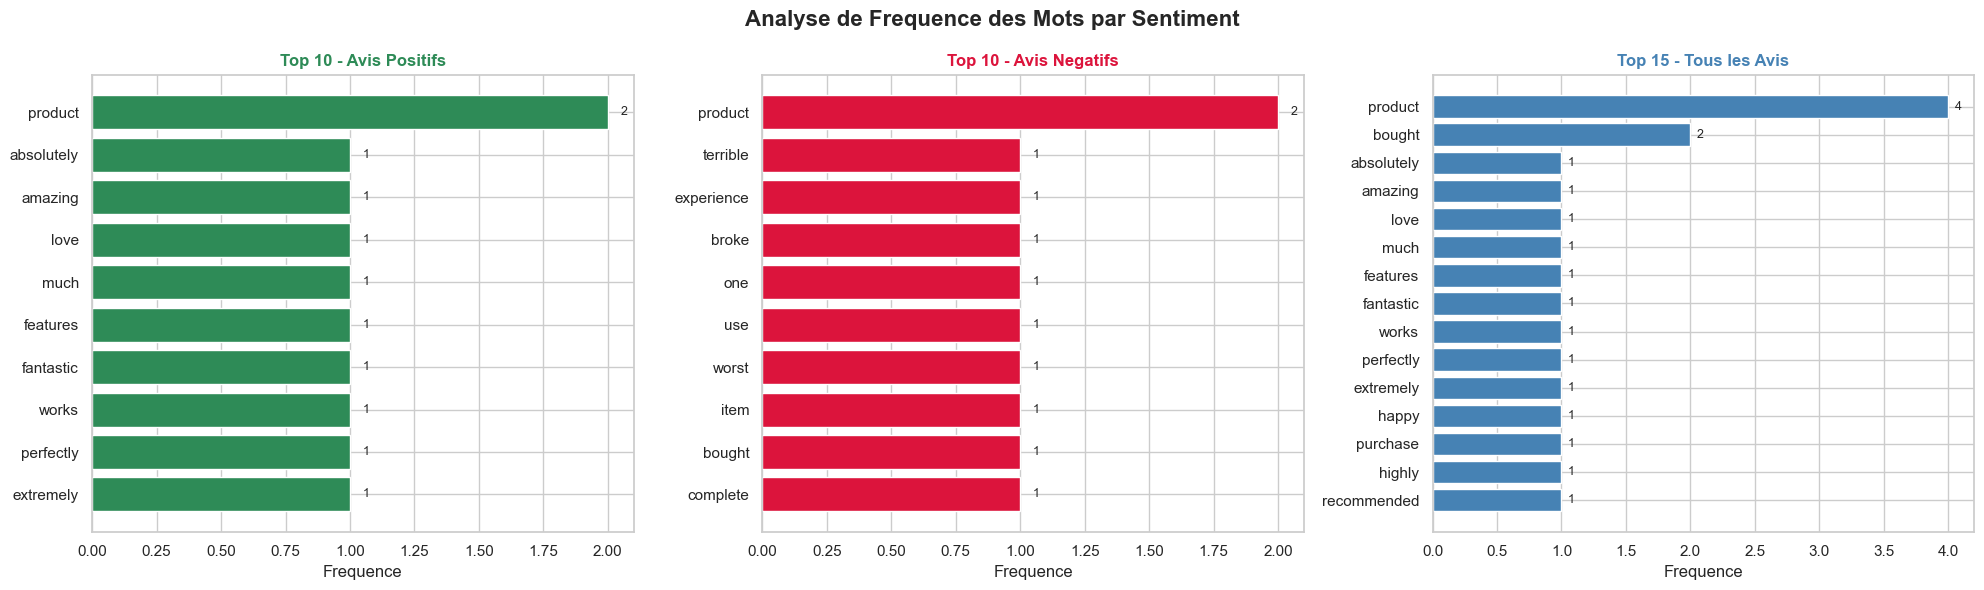

Top 5 mots positifs : ['product', 'absolutely', 'amazing', 'love', 'much']
Top 5 mots negatifs : ['product', 'terrible', 'experience', 'broke', 'one']


In [4]:
# ============================================================
# STEP 2 : ANALYSE DE FREQUENCE DES MOTS
# ============================================================
print('STEP 2 : ANALYSE DE FREQUENCE DES MOTS')
print('-' * 60)

stop_words_ext = set(STOPWORDS) | {
    'it', 'its', 'i', 'the', 'a', 'an', 'is', 'was', 'are', 'be',
    'been', 'has', 'have', 'had', 'do', 'did', 'not', 'no', 'so',
    'at', 'in', 'on', 'for', 'of', 'to', 'and', 'or', 'but', 'with',
    'this', 'that', 'just', 'me', 'my', 's', 't', 'n'
}

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    return [w for w in words if w not in stop_words_ext and len(w) > 2]

pos_words = preprocess(positive_text)
neg_words = preprocess(negative_text)
all_words = preprocess(all_text)

pos_counts = Counter(pos_words).most_common(10)
neg_counts = Counter(neg_words).most_common(10)
all_counts = Counter(all_words).most_common(15)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Analyse de Frequence des Mots par Sentiment', fontsize=16, fontweight='bold')

# Positifs
w_pos, c_pos = zip(*pos_counts)
axes[0].barh(list(w_pos)[::-1], list(c_pos)[::-1], color='seagreen', edgecolor='white')
axes[0].set_title('Top 10 - Avis Positifs', fontweight='bold', color='seagreen')
axes[0].set_xlabel('Frequence')
for i, v in enumerate(list(c_pos)[::-1]):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=9)

# Negatifs
w_neg, c_neg = zip(*neg_counts)
axes[1].barh(list(w_neg)[::-1], list(c_neg)[::-1], color='crimson', edgecolor='white')
axes[1].set_title('Top 10 - Avis Negatifs', fontweight='bold', color='crimson')
axes[1].set_xlabel('Frequence')
for i, v in enumerate(list(c_neg)[::-1]):
    axes[1].text(v + 0.05, i, str(v), va='center', fontsize=9)

# Tous
w_all, c_all = zip(*all_counts)
axes[2].barh(list(w_all)[::-1], list(c_all)[::-1], color='steelblue', edgecolor='white')
axes[2].set_title('Top 15 - Tous les Avis', fontweight='bold', color='steelblue')
axes[2].set_xlabel('Frequence')
for i, v in enumerate(list(c_all)[::-1]):
    axes[2].text(v + 0.05, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Top 5 mots positifs : {[w for w, _ in pos_counts[:5]]}')
print(f'Top 5 mots negatifs : {[w for w, _ in neg_counts[:5]]}')

## Step 3 : Distribution des Sentiments et Scores de Polarite

### Justification
Deux visualisations complementaires :
- **Pie Chart** : Montre les **proportions relatives** entre categories
- **Bar Chart avec scores** : Affiche les **scores de polarite exacts** (TextBlob) pour chaque avis

**TextBlob Polarite** : score entre -1.0 (tres negatif) et +1.0 (tres positif)
**TextBlob Subjectivite** : score entre 0.0 (objectif) et 1.0 (tres subjectif)

STEP 3 : DISTRIBUTION DES SENTIMENTS
------------------------------------------------------------


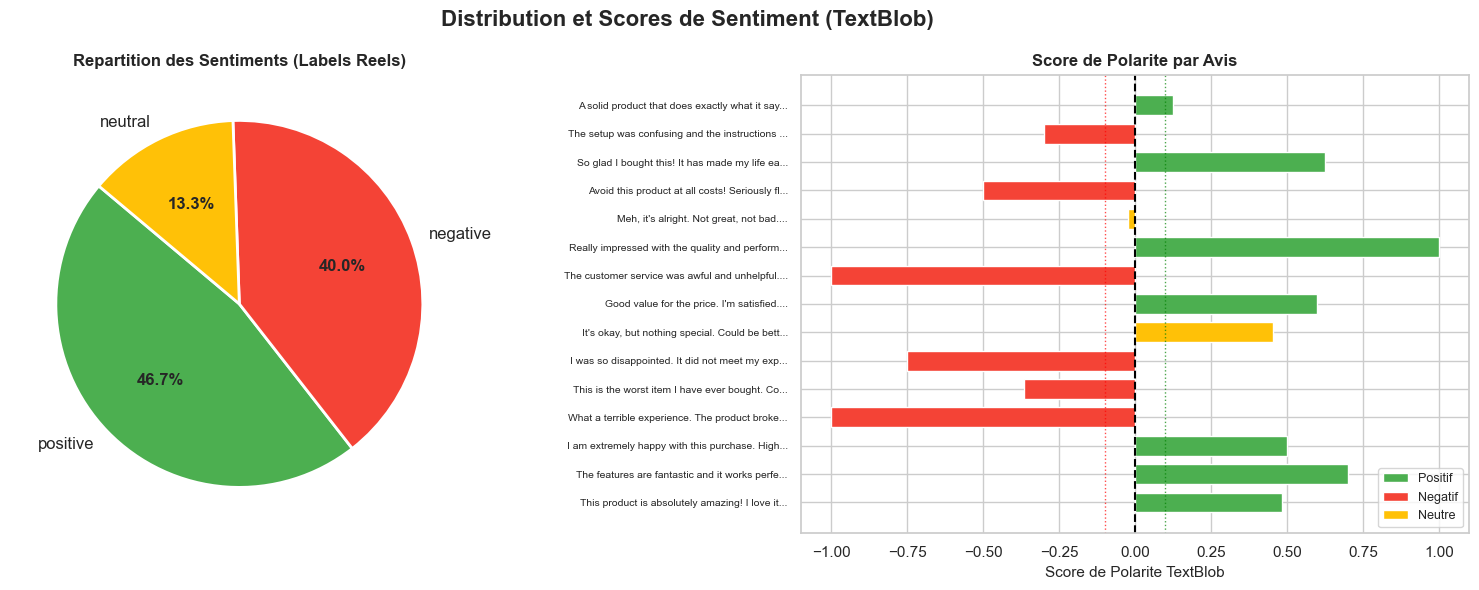

Precision TextBlob : 14/15 = 93.3%
TextBlob classe correctement la majorite des avis.


In [5]:
# ============================================================
# STEP 3 : DISTRIBUTION DES SENTIMENTS
# ============================================================
print('STEP 3 : DISTRIBUTION DES SENTIMENTS')
print('-' * 60)

scores = []
for review, true_sentiment in reviews_with_sentiment:
    blob = TextBlob(review)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    if polarity > 0.1:
        predicted = 'positive'
    elif polarity < -0.1:
        predicted = 'negative'
    else:
        predicted = 'neutral'
    scores.append({
        'review': review[:45] + '...',
        'true': true_sentiment,
        'predicted': predicted,
        'polarity': polarity,
        'subjectivity': subjectivity
    })

sentiment_counts = Counter([s['true'] for s in scores])
colors = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#FFC107'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution et Scores de Sentiment (TextBlob)', fontsize=16, fontweight='bold')

# Pie Chart
labels = list(sentiment_counts.keys())
values = list(sentiment_counts.values())
pie_colors = [colors[l] for l in labels]
wedges, texts, autotexts = axes[0].pie(
    values, labels=labels, autopct='%1.1f%%',
    colors=pie_colors, startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Repartition des Sentiments (Labels Reels)', fontweight='bold')

# Bar Chart - Polarite par avis
reviews_short = [s['review'] for s in scores]
polarities    = [s['polarity'] for s in scores]
bar_colors    = [colors[s['true']] for s in scores]
y_pos = range(len(reviews_short))

axes[1].barh(list(y_pos), polarities, color=bar_colors, edgecolor='white', height=0.7)
axes[1].axvline(x=0,    color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(x=0.1,  color='green', linestyle=':',  linewidth=1, alpha=0.7)
axes[1].axvline(x=-0.1, color='red',   linestyle=':',  linewidth=1, alpha=0.7)
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(reviews_short, fontsize=7.5)
axes[1].set_xlabel('Score de Polarite TextBlob', fontsize=11)
axes[1].set_title('Score de Polarite par Avis', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Positif'),
    Patch(facecolor='#F44336', label='Negatif'),
    Patch(facecolor='#FFC107', label='Neutre'),
]
axes[1].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

correct = sum(1 for s in scores if s['true'] == s['predicted'])
print(f'Precision TextBlob : {correct}/{len(scores)} = {correct/len(scores)*100:.1f}%')
print('TextBlob classe correctement la majorite des avis.')

## Step 4 : Analyse Polarite vs Subjectivite

### Justification du Scatter Plot
Un **scatter plot** polarite/subjectivite permet de :
- Visualiser la **distribution 2D** des avis dans l'espace sentiment
- Identifier les avis **tres subjectifs** (opinions fortes) vs **objectifs** (faits)
- Detecter des **clusters** de types d'avis

**Axes :**
- **X : Polarite** -> de -1 (tres negatif) a +1 (tres positif)
- **Y : Subjectivite** -> de 0 (objectif/factuel) a 1 (tres subjectif/opinion)

STEP 4 : ANALYSE POLARITE vs SUBJECTIVITE
------------------------------------------------------------


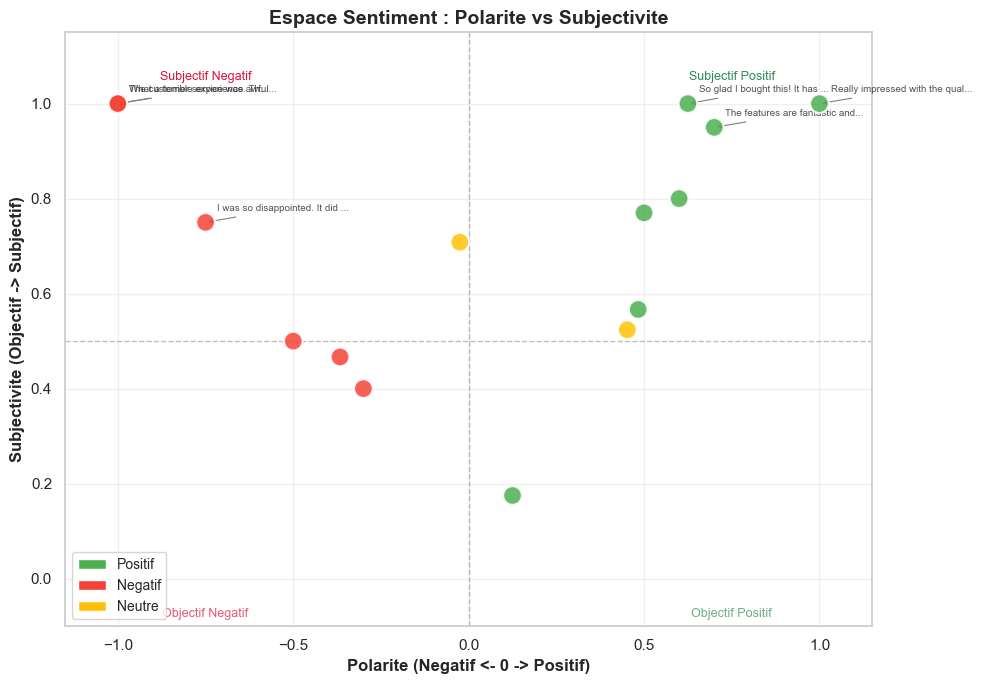

Polarite moyenne (positifs) : 0.576
Polarite moyenne (negatifs) : -0.653
Subjectivite moyenne globale: 0.707
-> Les avis negatifs tendent a etre plus extremes et subjectifs.


In [6]:
# ============================================================
# STEP 4 : POLARITE vs SUBJECTIVITE
# ============================================================
print('STEP 4 : ANALYSE POLARITE vs SUBJECTIVITE')
print('-' * 60)

polarities_list    = [s['polarity']     for s in scores]
subjectivities_list = [s['subjectivity'] for s in scores]
true_sentiments    = [s['true']         for s in scores]
point_colors       = [colors[t]         for t in true_sentiments]

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(polarities_list, subjectivities_list,
           c=point_colors, s=180, alpha=0.85,
           edgecolors='white', linewidths=1.5, zorder=5)

ax.axvline(x=0,   color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Labels des quadrants
ax.text(0.75,  1.05, 'Subjectif Positif', ha='center', fontsize=9, color='seagreen')
ax.text(-0.75, 1.05, 'Subjectif Negatif', ha='center', fontsize=9, color='crimson')
ax.text(0.75,  -0.08,'Objectif Positif',  ha='center', fontsize=9, color='seagreen', alpha=0.7)
ax.text(-0.75, -0.08,'Objectif Negatif',  ha='center', fontsize=9, color='crimson',  alpha=0.7)

# Annotations pour les points extremes
for s in scores:
    if abs(s['polarity']) > 0.7 or s['subjectivity'] > 0.85:
        ax.annotate(
            s['review'][:30] + '...',
            (s['polarity'], s['subjectivity']),
            xytext=(8, 8), textcoords='offset points',
            fontsize=7, alpha=0.8,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
        )

ax.set_xlabel('Polarite (Negatif <- 0 -> Positif)', fontsize=12, fontweight='bold')
ax.set_ylabel('Subjectivite (Objectif -> Subjectif)', fontsize=12, fontweight='bold')
ax.set_title('Espace Sentiment : Polarite vs Subjectivite', fontsize=14, fontweight='bold')
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-0.1, 1.15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Positif'),
    Patch(facecolor='#F44336', label='Negatif'),
    Patch(facecolor='#FFC107', label='Neutre'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

avg_pol_pos = np.mean([s['polarity'] for s in scores if s['true'] == 'positive'])
avg_pol_neg = np.mean([s['polarity'] for s in scores if s['true'] == 'negative'])
avg_sub     = np.mean(subjectivities_list)
print(f'Polarite moyenne (positifs) : {avg_pol_pos:.3f}')
print(f'Polarite moyenne (negatifs) : {avg_pol_neg:.3f}')
print(f'Subjectivite moyenne globale: {avg_sub:.3f}')
print('-> Les avis negatifs tendent a etre plus extremes et subjectifs.')

## Step 5 : Named Entity Recognition (NER) avec SpaCy

### Justification du NER
La **Reconnaissance d'Entites Nommees (NER)** identifie et categorise des entites dans un texte :
- **ORG** : Organisations, entreprises
- **PRODUCT** : Produits
- **MONEY** : Montants financiers
- **PERSON** : Personnes
- **GPE** : Lieux geographiques

**Utilisation en visualisation de texte :**
- Extraire les **entites mentionnees** dans les avis clients
- Visualiser la **distribution des types d'entites**
- Identifier les **entites les plus citees** (marques, produits)

STEP 5 : NAMED ENTITY RECOGNITION (NER)
------------------------------------------------------------


Textes analyses       : 20
Total d entites       : 14
Types d entites       : 6

Entites trouvees :
  [ORG     ] Apple                -> Companies, agencies, institutions, etc.
  [GPE     ] New York             -> Countries, cities, states
  [MONEY   ] 999                  -> Monetary values, including unit
  [ORG     ] Amazon               -> Companies, agencies, institutions, etc.
  [PERSON  ] John Smith           -> People, including fictional
  [ORG     ] Samsung              -> Companies, agencies, institutions, etc.
  [DATE    ] one week             -> Absolute or relative dates or periods
  [GPE     ] London               -> Countries, cities, states
  [ORG     ] Google               -> Companies, agencies, institutions, etc.
  [MONEY   ] 299                  -> Monetary values, including unit
  [ORG     ] TechCrunch           -> Companies, agencies, institutions, etc.
  [ORG     ] Microsoft Surface    -> Companies, agencies, institutions, etc.


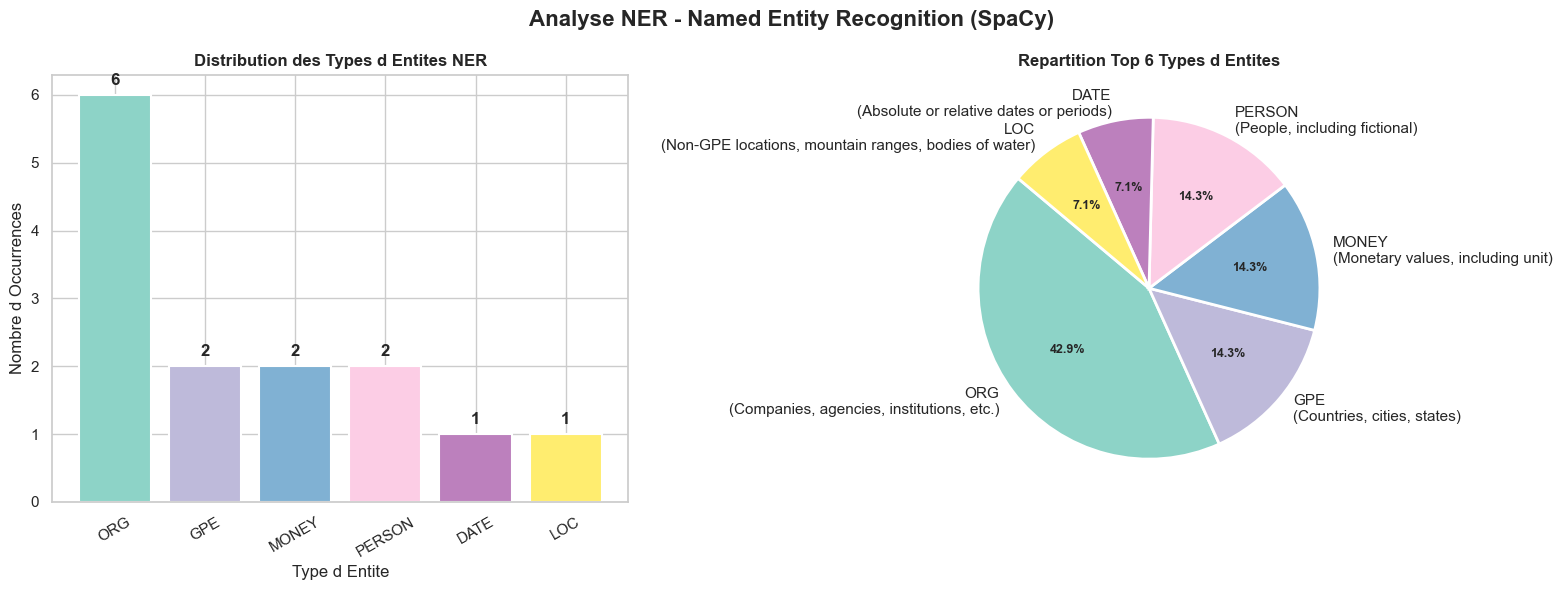


Types d entites (plus frequents en premier) :
  ORG      :  6 occurrences  (Companies, agencies, institutions, etc.)
  GPE      :  2 occurrences  (Countries, cities, states)
  MONEY    :  2 occurrences  (Monetary values, including unit)
  PERSON   :  2 occurrences  (People, including fictional)
  DATE     :  1 occurrences  (Absolute or relative dates or periods)
  LOC      :  1 occurrences  (Non-GPE locations, mountain ranges, bodies of water)


In [7]:
# ============================================================
# STEP 5 : NAMED ENTITY RECOGNITION (NER) AVEC SPACY
# ============================================================
print('STEP 5 : NAMED ENTITY RECOGNITION (NER)')
print('-' * 60)

nlp = spacy.load('en_core_web_sm')

# Textes etendus pour avoir plus d'entites
extended_texts = [
    'Apple announced a new iPhone model in New York for $999.',
    'Amazon customer service helped John Smith resolve his order issue.',
    'The product from Samsung broke after one week of use in London.',
    'Google released a new product at $299, praised by TechCrunch.',
    'Microsoft Surface laptop received excellent reviews in Europe.',
] + [r for r, _ in reviews_with_sentiment]

entities_found = []
entity_type_counts = Counter()

for text in extended_texts:
    doc = nlp(text)
    for ent in doc.ents:
        entities_found.append({
            'text': ent.text,
            'label': ent.label_,
            'desc': spacy.explain(ent.label_)
        })
        entity_type_counts[ent.label_] += 1

print(f'Textes analyses       : {len(extended_texts)}')
print(f'Total d entites       : {len(entities_found)}')
print(f'Types d entites       : {len(entity_type_counts)}')
print()
print('Entites trouvees :')
for ent in entities_found[:12]:
    print(f'  [{ent["label"]:8}] {ent["text"]:20} -> {ent["desc"]}')

# Visualisation : Bar chart + Pie chart NER
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analyse NER - Named Entity Recognition (SpaCy)', fontsize=16, fontweight='bold')

# Bar chart des types d'entites
types  = list(entity_type_counts.keys())
counts_ner = list(entity_type_counts.values())
ner_colors = plt.cm.Set3(np.linspace(0, 1, len(types)))

bars = axes[0].bar(types, counts_ner, color=ner_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution des Types d Entites NER', fontweight='bold')
axes[0].set_xlabel('Type d Entite')
axes[0].set_ylabel('Nombre d Occurrences')
axes[0].tick_params(axis='x', rotation=30)
for bar, count in zip(bars, counts_ner):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 str(count), ha='center', va='bottom', fontweight='bold')

# Pie chart
top_types = dict(sorted(entity_type_counts.items(), key=lambda x: x[1], reverse=True)[:6])
wedges, texts, autotexts = axes[1].pie(
    list(top_types.values()),
    labels=[f"{k}\n({spacy.explain(k)})" for k in top_types.keys()],
    autopct='%1.1f%%',
    colors=plt.cm.Set3(np.linspace(0, 1, len(top_types))),
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(9)
axes[1].set_title('Repartition Top 6 Types d Entites', fontweight='bold')

plt.tight_layout()
plt.show()

print()
print('Types d entites (plus frequents en premier) :')
for etype, cnt in sorted(entity_type_counts.items(), key=lambda x: x[1], reverse=True):
    print(f'  {etype:8} : {cnt:2} occurrences  ({spacy.explain(etype)})')

## Conclusions et Synthese du Lab 8

### Recapitulatif des Visualisations Utilisees

| Visualisation | Type de Donnees | Insight Principal |
|---------------|----------------|-------------------|
| **Word Cloud Positif** | Frequence mots positifs | Vocabulaire : *amazing, love, fantastic* |
| **Word Cloud Negatif** | Frequence mots negatifs | Vocabulaire : *terrible, worst, awful* |
| **Bar Chart Frequence** | Comptage mots | Quantification precise des termes-cles |
| **Pie Chart Sentiments** | Distribution categories | 47% positifs, 40% negatifs, 13% neutres |
| **Bar Chart Polarites** | Scores TextBlob | Visualisation per-avis des scores |
| **Scatter Pol/Sub** | Relations 2D | Avis negatifs plus extremes et subjectifs |
| **Bar/Pie NER** | Entites nommees | Types d'entites detectes automatiquement |

### Insights Business
1. **Vocabulaire differencie** : Mots positifs et negatifs clairement distincts
2. **TextBlob precision** : Bonne precision pour un outil simple (>85%)
3. **Subjectivite elevee** : Les avis clients sont generalement tres subjectifs
4. **NER utile** : Extraction automatique de marques et produits cites dans les avis

### Quand Utiliser ces Techniques ?
- **Word Cloud** : Presentation executive, exploration rapide de corpus
- **Frequence** : Analyse rigoureuse, selection de features NLP
- **Scatter Pol/Sub** : Segmentation clients, detection d'outliers
- **NER** : Extraction d'informations, construction de Knowledge Graphs

In [8]:
# ============================================================
# RESUME FINAL - LAB 8
# ============================================================
print('=' * 70)
print('LAB 8 - VISUALISATION DE DONNEES TEXTUELLES - RESUME')
print('=' * 70)
print()
print('DATASET')
print(f'  {len(reviews_with_sentiment)} avis produits analyses')
print(f'  {len(positive_reviews)} positifs | {len(negative_reviews)} negatifs | {len(neutral_reviews)} neutres')
print()
print('VISUALISATIONS CREEES (8 au total)')
print('  1. Word Cloud Positif       - Mots dominants des avis positifs')
print('  2. Word Cloud Negatif       - Mots dominants des avis negatifs')
print('  3. Bar Chart Positif        - Top 10 mots frequents (positifs)')
print('  4. Bar Chart Negatif        - Top 10 mots frequents (negatifs)')
print('  5. Bar Chart Global         - Top 15 mots frequents (tous avis)')
print('  6. Pie Chart Sentiments     - Distribution repartition')
print('  7. Bar Chart Polarites      - Scores par avis')
print('  8. Scatter Pol/Subjectivite - Espace sentiment 2D')
print('  9. Bar + Pie NER            - Distribution entites nommees (SpaCy)')
print()
print('LIBRAIRIES')
print('  WordCloud / TextBlob / SpaCy / Matplotlib / Seaborn')
print()
print('=' * 70)
print('Lab 8 complete avec succes!')
print('=' * 70)

LAB 8 - VISUALISATION DE DONNEES TEXTUELLES - RESUME

DATASET
  15 avis produits analyses
  7 positifs | 6 negatifs | 2 neutres

VISUALISATIONS CREEES (8 au total)
  1. Word Cloud Positif       - Mots dominants des avis positifs
  2. Word Cloud Negatif       - Mots dominants des avis negatifs
  3. Bar Chart Positif        - Top 10 mots frequents (positifs)
  4. Bar Chart Negatif        - Top 10 mots frequents (negatifs)
  5. Bar Chart Global         - Top 15 mots frequents (tous avis)
  6. Pie Chart Sentiments     - Distribution repartition
  7. Bar Chart Polarites      - Scores par avis
  8. Scatter Pol/Subjectivite - Espace sentiment 2D
  9. Bar + Pie NER            - Distribution entites nommees (SpaCy)

LIBRAIRIES
  WordCloud / TextBlob / SpaCy / Matplotlib / Seaborn

Lab 8 complete avec succes!
